<a href="https://colab.research.google.com/github/ayoub-ouichen/machine-learning/blob/main/ViT_detect_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

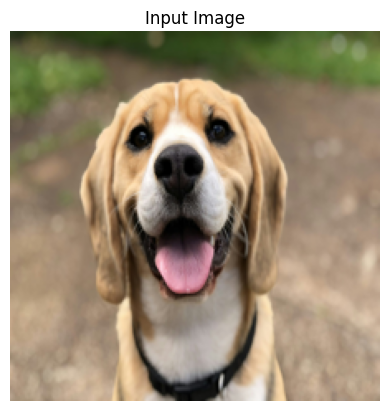


TOP 5 PREDICTIONS:

beagle: 0.6970
English foxhound: 0.2217
Walker hound, Walker foxhound: 0.0531
Brittany spaniel: 0.0038
EntleBucher: 0.0030


In [ ]:
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests
import torch
import matplotlib.pyplot as plt

model_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)

# Load image
url = "https://images.unsplash.com/photo-1543466835-00a7907e9de1?fm=jpg&q=60&w=3000&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8ZG9nJTIwYnJlZWRzfGVufDB8fDB8fHww"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
image = image.resize((224, 224))

plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

# Preprocess
inputs = processor(images=image, return_tensors="pt")

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

# Get probabilities (IMPORTANT for "confidence")
probs = torch.nn.functional.softmax(logits, dim=-1)

top5 = torch.topk(probs, 5)

print("\nTOP 5 PREDICTIONS:\n")

for i in range(5):
    idx = top5.indices[0][i].item()
    score = top5.values[0][i].item()
    label = model.config.id2label[idx]

    print(f"{label}: {score:.4f}")